## Import libraries

In [1]:
import yfinance as yf 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## Data

In [2]:
ticker = "SGO.PA"          # Saint-Gobain (Euronext Paris)
df = yf.download(ticker, start="2000-01-01",end="2013-12-31", progress=False)

close = df["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]


YF.download() has changed argument auto_adjust default to True


In [3]:
close.head()

Date
2000-01-03    22.300943
2000-01-04    21.884968
2000-01-05    21.619207
2000-01-06    21.526766
2000-01-07    21.214783
Name: SGO.PA, dtype: float64

On note $S_t$ le prix de l’actif à l’instant $t$.  
Nous considérons ici que $t = 0, 1, 2, \ldots$ désigne des jours.


On peut considérer la variation quotidienne définie par  
$$V_t = S_t - S_{t-1}.$$

$ V_t$ est exprimée en euros €.



In [4]:
df["V_t"] = close.diff()
df['V_t']

Date
2000-01-03         NaN
2000-01-04   -0.415976
2000-01-05   -0.265760
2000-01-06   -0.092442
2000-01-07   -0.311983
                ...   
2013-12-20    0.320196
2013-12-23    0.145199
2013-12-24   -0.052120
2013-12-27    0.543579
2013-12-30   -0.156372
Name: V_t, Length: 3608, dtype: float64

ou bien le rendement quotidien (variation relative) défini par  
$$R_t = \frac{S_t - S_{t-1}}{S_{t-1}}.$$

$R_t$ est exprimé en pourcentage.

In [5]:
df["R_t"] = close.pct_change()

In [6]:
plot_df = pd.DataFrame({"V_t": close.diff(), "R_t": close.pct_change()}).dropna()

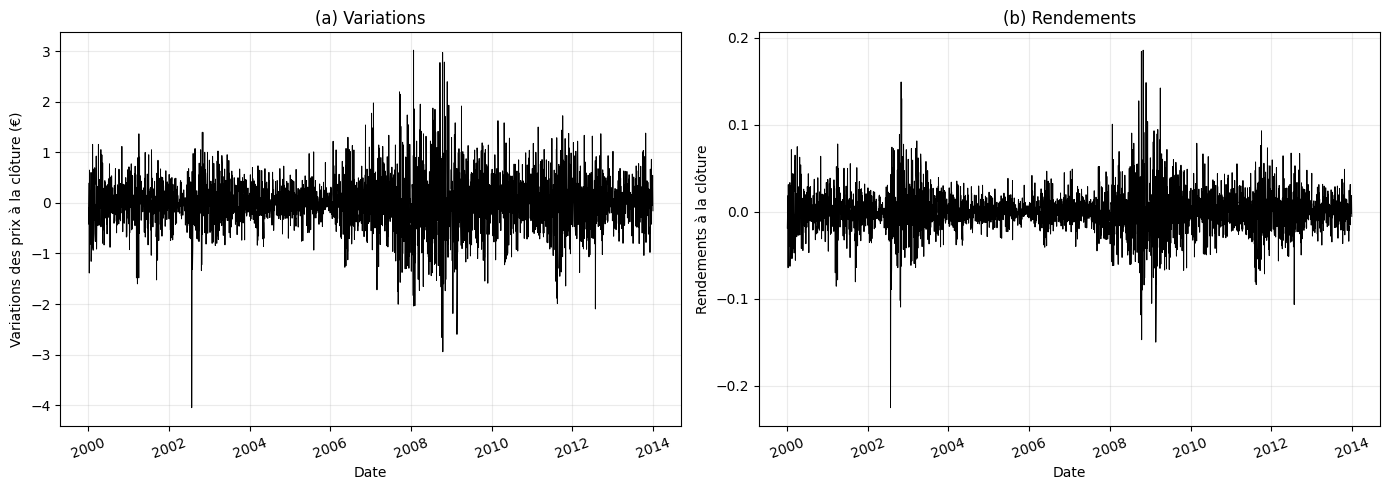

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(plot_df.index, plot_df["V_t"], color="black", linewidth=0.7)
axes[0].set_title("(a) Variations")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Variations des prix à la clôture (€)")
axes[0].grid(alpha=0.25)

axes[1].plot(plot_df.index, plot_df["R_t"], color="black", linewidth=0.7)
axes[1].set_title("(b) Rendements")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Rendements à la clôture")
axes[1].grid(alpha=0.25)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

La variation absolue dépend du prix de référence :
$$V_t = S_t - S_{t-1}.$$

Le rendement corrige cet effet d’échelle :
$$R_t = \frac{S_t - S_{t-1}}{S_{t-1}}.$$

Exemple : une hausse de \(+1\,€\)
- de \(10\) à \(11\) donne \(R_t = 10\%\),
- de \(200\) à \(201\) donne \(R_t = 0{,}5\%\).

Donc \(V_t\) dépend fortement du niveau de prix, alors que \(R_t\) est comparable.


In [8]:
S1_prev, S1_now = 10, 11
S2_prev, S2_now = 200, 201

V1 = S1_now - S1_prev
V2 = S2_now - S2_prev

R1 = (S1_now - S1_prev) / S1_prev
R2 = (S2_now - S2_prev) / S2_prev

print("Cas 1:", "V_t =", V1, "€ ; R_t =", f"{R1*100:.1f}%")
print("Cas 2:", "V_t =", V2, "€ ; R_t =", f"{R2*100:.1f}%")


Cas 1: V_t = 1 € ; R_t = 10.0%
Cas 2: V_t = 1 € ; R_t = 0.5%


Dans la figure ci-dessus, les grands pics correspondent à des jours où la variation quotidienne
est très élevée (en valeur absolue), à la hausse comme à la baisse.

Ils traduisent des mouvements brusques du prix, souvent liés à :
- des annonces importantes sur l’entreprise (résultats, opérations financières, etc.) ;
- des chocs de marché (crise, nouvelles macroéconomiques, variations de taux, etc.).

Ces pics indiquent donc des périodes de forte volatilité et de risque plus élevé.


En pratique, on considère le log-rendement quotidien défini par  
$$L_t = \ln\!\left(\frac{S_{t+1}}{S_{t}}\right).$$


Ainsi, le prix \(S_{t+1}\) est relié à \(S_t\) et \(L_{t+1}\) par  
$$S_{t+1} = S_t\,e^{L_{t}}.$$


On a
$$L_t=\ln\!\left(\frac{S_t}{S_{t-1}}\right)=\ln(1+R_t),\quad\text{car }R_t=\frac{S_t-S_{t-1}}{S_{t-1}}.$$

Or, pour $x \to 0$,

$$\ln(1+x)=x-\frac{x^2}{2}+\frac{x^3}{3}-\cdots$$

Donc
$$L_t=\ln(1+R_t)=R_t-\frac{R_t^2}{2}+\frac{R_t^3}{3}-\cdots$$

Ainsi, si $R_t$ est petit en valeur absolue,
$$L_t \approx R_t.$$

L’erreur principale est d’ordre $\frac{R_t^2}{2}$, donc elle augmente quand $|R_t|$ (et donc $|L_t|$) devient grand : c’est pourquoi l’écart entre log-rendement et rendement est faible pour petits mouvements, et plus visible pour grands pics.


In [9]:
df['L_t'] = np.log(close/close.shift(1))

In [10]:
plot_df_2 = pd.DataFrame({'R_t' : df['R_t'], 'L_t' : df['L_t']}).dropna()

In [11]:
plot_df_2

,R_t,L_t
Date,,
2000-01-04,-0.018653,-0.018829
2000-01-05,-0.012144,-0.012218
2000-01-06,-0.004276,-0.004285
2000-01-07,-0.014493,-0.014599
2000-01-10,0.018518,0.018349
...,...,...
2013-12-20,0.011107,0.011046
2013-12-23,0.004981,0.004969
2013-12-24,-0.001779,-0.001781


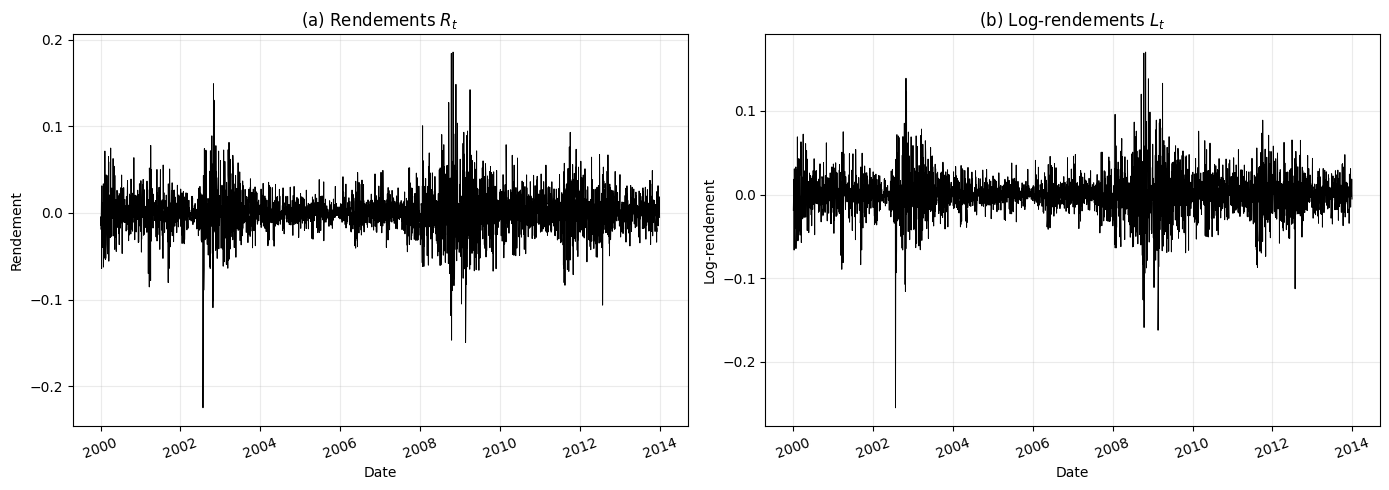

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(plot_df_2.index, plot_df_2["R_t"], color="black", linewidth=0.7)
axes[0].set_title("(a) Rendements $R_t$")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Rendement")
axes[0].grid(alpha=0.25)

axes[1].plot(plot_df_2.index, plot_df_2["L_t"], color="black", linewidth=0.7)
axes[1].set_title("(b) Log-rendements $L_t$")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log-rendement")
axes[1].grid(alpha=0.25)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

En prenant \(p\) un nombre de jours (par exemple \(p=30\) pour mensuel, \(p=252\) pour annuel), on définit :

$
V_{t;p} = S_{t+p} - S_{t}
$

$
R_{t;p} = \frac{S_{t+p} - S_{t}}{S_{t}} = \frac{S_{t+p}}{S_{t}} - 1
$

$
L_{t;p} = \ln\!\left(\frac{S_{t+p}}{S_{t}}\right)
$


On note
$$
L_{t;p}=\ln\!\left(\frac{S_{t+p}}{S_t}\right).
$$

Alors, pour $p,q\ge 1$ :
$$
L_{t;p+q}
=\ln\!\left(\frac{S_{t+p+q}}{S_t}\right)
=\ln\!\left(\frac{S_{t+p+q}}{S_{t+p}}\cdot\frac{S_{t+p}}{S_t}\right)
=\ln\!\left(\frac{S_{t+p+q}}{S_{t+p}}\right)+\ln\!\left(\frac{S_{t+p}}{S_t}\right)
=L_{t+p;q}+L_{t;p}.
$$

Donc
$$
\boxed{L_{t;p+q}=L_{t;p}+L_{t+p;q}}
$$

Ensuite,
$$
L_{t;p}
=\ln\!\left(\frac{S_{t+p}}{S_t}\right)
=\ln\!\left(\frac{S_{t+1}}{S_t}\cdot\frac{S_{t+2}}{S_{t+1}}\cdots\frac{S_{t+p}}{S_{t+p-1}}\right)
=\sum_{k=0}^{p-1}\ln\!\left(\frac{S_{t+k+1}}{S_{t+k}}\right).
$$

Or $\ln\!\left(\frac{S_{t+k+1}}{S_{t+k}}\right)=L_{t+k}$ (log-rendement journalier), donc
$$
\boxed{L_{t;p}=L_t+L_{t+1}+\cdots+L_{t+p-1}.}
$$


Nous venons de montrer que les log-rendements sont additifs dans le temps.

## Un modèle aléatoire : accroissements indépendants

Nous cherchons maintenant à trouver un modèle aléatoire qui réplique les *(log-)rendements*<sup>2</sup>.  
Nous supposons que les log-rendements $L_t$ sont des réalisations issues d’une même loi et que ces réalisations sont indépendantes.


La densité empirique de $L_t$ est tracée à l’aide d’un histogramme ci-dessous.

On remarque que sa forme est proche de celle d’une loi normale.  

Prouvons mathématiquement si $L_t$ suit une loi normale ?


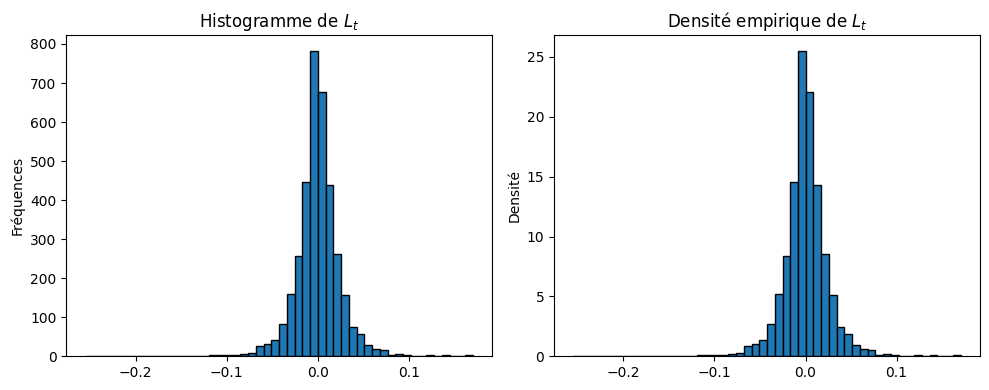

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1) Histogramme en fréquences
axes[0].hist(df['L_t'], bins=50, edgecolor="black")
axes[0].set_ylabel("Fréquences")
axes[0].set_title("Histogramme de $L_t$")

# 2) Histogramme normalisé en densité
axes[1].hist(df['L_t'], bins=50, density=True, edgecolor="black")
axes[1].set_ylabel("Densité")
axes[1].set_title("Densité empirique de $L_t$")

plt.tight_layout()
plt.show()

Les deux histogrammes sont construits à partir des mêmes données, mais avec deux normalisations différentes.

On considère un échantillon de taille $n$, réparti en classes $I_j$ de même largeur $h$.  
On note $n_j$ le nombre d’observations appartenant à la classe $I_j$.

Dans l’histogramme de fréquences, la hauteur de la barre associée à la classe $I_j$ est proportionnelle à l’effectif $n_j$.

Dans l’histogramme de densité, la hauteur de la barre associée à la classe $I_j$ est définie par
$$
\frac{n_j}{n h}.
$$

L’aire de cette barre vaut alors
$$
\frac{n_j}{n h}\times h=\frac{n_j}{n}.
$$

En sommant sur toutes les classes, on obtient l’aire totale de l’histogramme :
$$
\sum_j \frac{n_j}{n}
= \frac{1}{n}\sum_j n_j
= \frac{n}{n}
= 1.
$$

Ainsi, le second histogramme est normalisé de sorte que son aire totale soit égale à $1$.  
Il peut donc être interprété comme une approximation de la densité de probabilité de $L_t$.


Pour les données considérées ici, on obtient $n = 3607$ réalisations de $L_t$.

Les moments empiriques valent alors :
$$
 Moyenne : \mu_n = \frac{1}{n}\sum_{t=1}^n L_t \approx  7.87 \times 10^{-5}, 
$$

$$
Ecart-type : \sigma_n = \sqrt{\frac{1}{n-1}\sum_{t=1}^n L_t^2 - \mu_n^2}
\approx 0.0243,
$$

$$
 Skewness : s_n = \frac{\sqrt{n}\sum_{t=1}^n (L_t-\mu_n)^3}{\left(\sum_{t=1}^n (L_t-\mu_n)^2\right)^{3/2}}
\approx -0.263,
$$

$$
 Kurtosis : \kappa_n = \frac{n\sum_{t=1}^n (L_t-\mu_n)^4}{\left(\sum_{t=1}^n (L_t-\mu_n)^2\right)^2}
\approx 11.443.
$$


In [14]:
L_t = np.log(close / close.shift(1)).dropna()

n = len(L_t)
mu_n = L_t.mean()
sigma_n = np.sqrt((L_t.pow(2).sum() / (n - 1)) - mu_n**2)

centered = L_t - mu_n
s_n = np.sqrt(n) * centered.pow(3).sum() / (centered.pow(2).sum() ** 1.5)
kappa_n = n * centered.pow(4).sum() / (centered.pow(2).sum() ** 2)

n, mu_n, sigma_n, s_n, kappa_n



(3607,
 7.876991275296513e-05,
 0.024314011373994616,
 -0.2636965274462029,
 11.443255673441339)

La moyenne $\mu_n$ est proche de $0$.  
Le coefficient de skewness $s_n$ donne une idée du manque de symétrie de la loi commune des $L_t$.  
Le coefficient de kurtosis $\kappa_n$ donne une idée de la taille du pic.


Soit
$$
Z \sim \mathcal N(\mu,\sigma^2), \qquad \sigma>0.
$$
Posons la variable centrée-réduite
$$
X=\frac{Z-\mu}{\sigma}.
$$
Alors
$$
X\sim \mathcal N(0,1).
$$

Par définition,
$$
s=\mathbb E\!\left[\left(\frac{Z-\mu}{\sigma}\right)^3\right]=\mathbb E[X^3],
\qquad
\kappa=\mathbb E\!\left[\left(\frac{Z-\mu}{\sigma}\right)^4\right]=\mathbb E[X^4].
$$
Donc $s$ et $\kappa$ ne dépendent que de la loi de $X$, qui est toujours $\mathcal N(0,1)$ : ils ne dépendent donc pas de $\mu$ ni de $\sigma$.

Pour $s$ :
la densité $ \phi $ de $\mathcal N(0,1)$ est paire, et la fonction $ x\mapsto x^3$ est impaire, donc
$$
\mathbb E[X^3]=\int_{-\infty}^{+\infty} x^3 \phi(x)\,dx=0.
$$
Ainsi
$$
s=0.
$$

Pour $\kappa$ :
pour une normale centrée réduite, le moment d’ordre 4 vaut
$$
\mathbb E[X^4]=3.
$$


Donc
$$
\kappa=3.
$$


et ces quantités ne dépendent pas de $\mu$ ni de $\sigma$.


Text(0.5, 1.0, "Densité empirique de Lt et densité de la loi normale de moyenne mu_n et d'écart type sigma n")

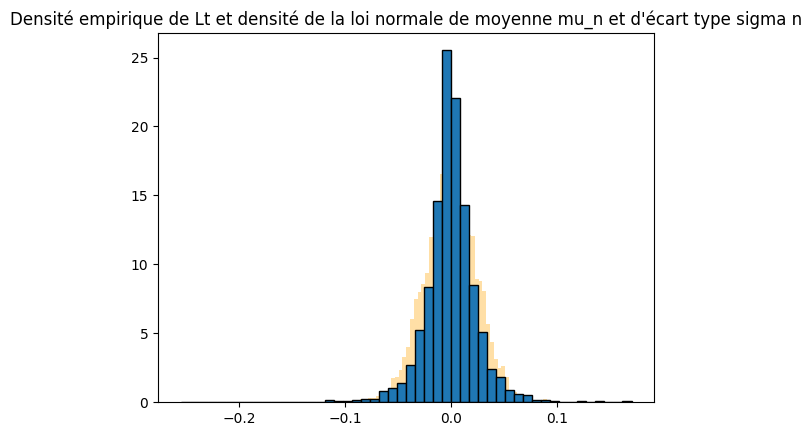

In [16]:
x_norm = np.random.normal(loc=mu_n, scale=sigma_n, size=len(L_t))

plt.hist(x_norm, bins=50, density=True, alpha=0.35, color="orange")

plt.hist(df['L_t'], density = True, bins=50, edgecolor='black')

plt.title("Densité empirique de Lt et densité de la loi normale de moyenne mu_n et d'écart type sigma n")

Nous constatons dans le graphique ci-dessus que la loi de $L_t$ n'est pas une loi normale.

En effet,
- Elle est plus « pointue » ($\kappa > 3$), et la queue de distribution semble plus lourde.
- Elle n'est pas complètement symétrique. Cela est plus difficile à détecter à l'œil, 
mais c'est ce que signifie $s \neq 0$.


In [27]:
log_gains = df[ df['L_t'] > 0 ]['L_t'].sort_values(ascending=True).values

In [30]:
log_loss = df[ df['L_t'] <= 0 ]['L_t'].sort_values(ascending=False).values

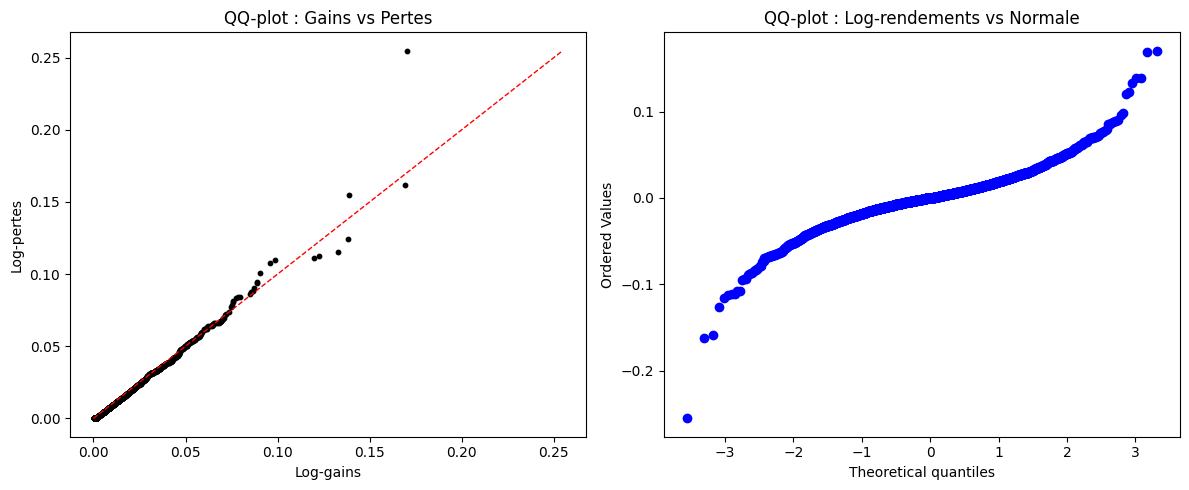

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


n = min(len(log_gains), len(log_loss))
gains_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(log_gains)), log_gains)
loss_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(log_loss)), log_loss)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.scatter(gains_interp, -loss_interp, s=10, color='black')
lim = max(gains_interp.max(), (-loss_interp).max())
plt.plot([0, lim], [0, lim], 'r--', linewidth=1)  
plt.xlabel('Log-gains')
plt.ylabel('Log-pertes')
plt.title('QQ-plot : Gains vs Pertes')


plt.subplot(1, 2, 2)
stats.probplot(df['L_t'].values, dist="norm", plot=plt)
plt.title('QQ-plot : Log-rendements vs Normale')

plt.tight_layout()
plt.show()

Nous constatons que sur la figure ci-dessus les 
points sont alignés sauf pour les grandes variations. Cela explique le fait que $s \neq 0$.

> **Rem ** La justification d'un QQ-plot est que si $X_1, \ldots, X_n$ suit une loi 
> de fonction de répartition $F$, alors lorsque $n$ est grand, $X_{(k)}$ est proche du 
> quantile $q_{k/n}$ défini par $q_{k/n} = F^{-1}(k/n)$ pour l'inverse continu à gauche 
> $F^{-1}$ de $F$ lorsque $X_{(1)} \leq X_{(2)} \leq \cdots \leq X_{(n)}$. $\diamond$
